# **Neural Language Models and Word Embeddings**

![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-ML-Explainers/main/assets/rainbow-divider.png)

# 📖 TABLE OF CONTENTS

- [Intro](#Intro)
- [Setup](#Setup)
- [Why Does This Matter?](#Why-Does-This-Matter?)
- [Building Intuition](#Building-Intuition)
  - [What to Look For: Embedding Visualization](#What-to-Look-For:-Embedding-Visualization)
- [The Mathematics](#The-Mathematics)
  - [Code Walkthrough: Manual Forward Pass](#Code-Walkthrough:-Manual-Forward-Pass)
  - [What to Look For: Manual Forward Pass Results](#What-to-Look-For:-Manual-Forward-Pass-Results)
- [Let's Build It — Component by Component](#Let's-Build-It-—-Component-by-Component)
  - [Code Walkthrough: BengioLM Class](#Code-Walkthrough:-BengioLM-Class)
  - [Code Walkthrough: Data Preparation](#Code-Walkthrough:-Data-Preparation)
  - [Code Walkthrough: Train BengioLM Model](#Code-Walkthrough:-Train-BengioLM-Model)
  - [What to Look For: Train BengioLM Results](#What-to-Look-For:-Train-BengioLM-Results)
  - [Code Walkthrough: Visualize Embeddings](#Code-Walkthrough:-Visualize-Embeddings)
  - [What to Look For: Visualize Embeddings Results](#What-to-Look-For:-Visualize-Embeddings-Results)
- [Word2Vec](#Word2Vec)
  - [Code Walkthrough: Word2VecSkipGram Class](#Code-Walkthrough:-Word2VecSkipGram-Class)
  - [Code Walkthrough: Data Preparation](#Code-Walkthrough:-Data-Preparation)
  - [Code Walkthrough: Train Word2VecSkipGram Model](#Code-Walkthrough:-Train-Word2VecSkipGram-Model)
  - [What to Look For: Train Word2VecSkipGram Results](#What-to-Look-For:-Train-Word2VecSkipGram-Results)
  - [Code Walkthrough: Visualize Embeddings](#Code-Walkthrough:-Visualize-Embeddings)
  - [What to Look For: Visualize Embeddings Results](#What-to-Look-For:-Visualize-Embeddings-Results)
  - [Measure Cosine Similarity Between Word Pairs](#Measure-Cosine-Similarity-Between-Word-Pairs)
- [References](#References)

![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-ML-Explainers/main/assets/rainbow-divider.png)

# Intro

In this notebook, we are going to dive deep into how neural networks revolutionized Natural Language Processing (NLP). We will build some foundational models, understand how words get their meaning, and even see the limitations that led us to the Transformer. By the end, you will have a clear understanding of what Embeddings are and why they are so powerful.

![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-ML-Explainers/main/assets/rainbow-divider.png)

# Setup

Before we jump in, lets quickly run the setup cell. It checks whether you have a GPU available which will speed things up and sets up some random seeds for reproducibility. This ensures that when you run the code, you will get the same results as I do.

In [ ]:
# 🔧 Setup: Run this cell first!
# Check GPU availability and install dependencies

import torch
import sys

# Check GPU
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"✅ GPU available: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    device = torch.device('cpu')
    print("⚠️ No GPU detected. Some cells may run slowly.")
    print("   Go to Runtime → Change runtime type → GPU")

print(f"\n📦 Python {sys.version.split()[0]}")
print(f"🔥 PyTorch {torch.__version__}")

# Set random seeds for reproducibility
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"🎲 Random seed set to {SEED}")

%matplotlib inline

✅ GPU available: Tesla T4
   Memory: 15.6 GB

📦 Python 3.12.13
🔥 PyTorch 2.11.0+cu128
🎲 Random seed set to 42


![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-ML-Explainers/main/assets/rainbow-divider.png)

# Why Does This Matter?

In the previous notebook, we built an N-gram language model that predicts the next word by counting. It works, but it has two fatal flaws: it assigns zero probability to unseen word combinations, and it has absolutely no notion that similar words should behave similarly. Today we are tackling these issues head on.

In 2003, Yoshua Bengio asked a simple question: **what if, instead of counting words, we could learn to represent them as vectors?** His answer — the **Neural Probabilistic Language Model** — is one of the most important papers in the history of NLP and laid the ground work for almost everything we do in NLP today.

The core idea: represent each word as a **dense vector of real numbers** (an embedding), then use a neural network to predict the next word from these embeddings. Words that appear in similar contexts end up with similar vectors, so knowledge transfers automatically from one word to another.

In this notebook, you will:
- Build Bengio's neural language model from scratch in PyTorch
- Train word embeddings and visualize semantic relationships
- Implement Word2Vec (Skip-gram) and see the famous King - Man + Woman = Queen
- Build a simple RNN language model and see its limitations
- Understand why fixed-context and sequential processing are fundamental bottlenecks

Let us move from counting to learning.

![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-ML-Explainers/main/assets/rainbow-divider.png)

# Building Intuition

To really grasp this idea, let's use an analogy. Imagine you are in a foreign city looking for a good restaurant. The N-gram approach is like having a massive phone book: you look up the exact address. If the restaurant is not in the book, you are stuck.

The neural approach is like having a **map.** Even if the specific restaurant is not marked, you can see that there is a cluster of restaurants in a particular neighborhood and walk there. The "map" is the **embedding space**, and similar words live in the same neighborhood.

Let us see what "word as a number" means in practice.

## What to Look For: Embedding Visualization

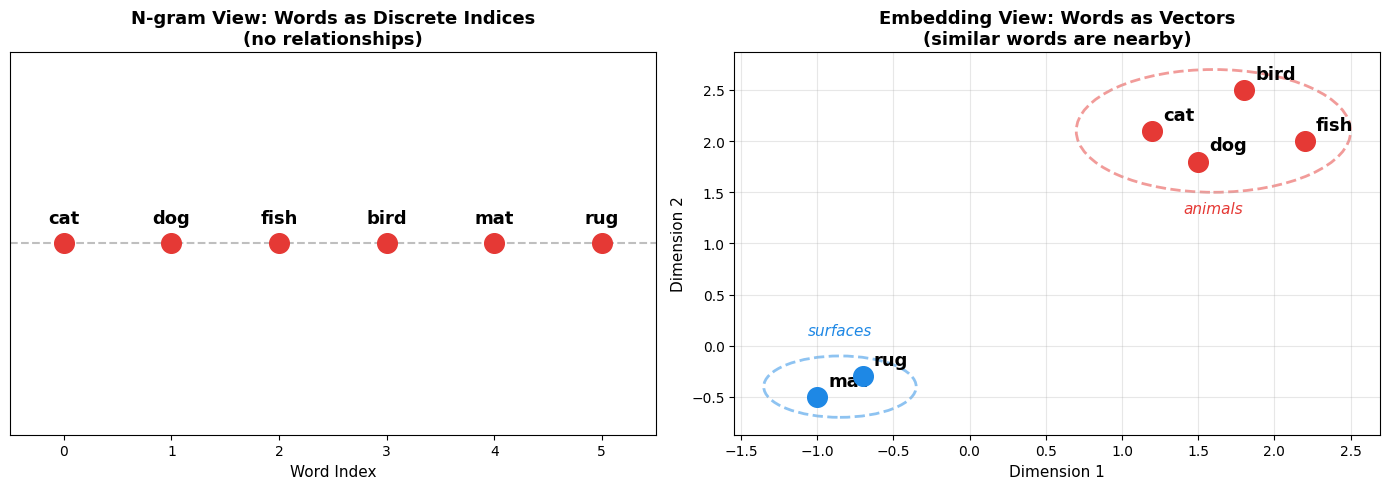

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

# In an N-gram model, each word is just an INDEX — a meaningless integer.
# "cat" = 0, "dog" = 1, "fish" = 2
# There is NO relationship between these numbers.

# In a neural model, each word is a VECTOR — a point in continuous space.
# "cat" = [0.2, 0.8, -0.1, 0.5, ...]
# "dog" = [0.3, 0.7, -0.2, 0.4, ...]  <-- close to cat!
# "fish" = [-0.5, 0.1, 0.9, -0.3, ...]  <-- farther away

# Let's visualize this difference
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: N-gram view (discrete indices)
words = ["cat", "dog", "fish", "bird", "mat", "rug"]
indices = list(range(len(words)))

axes[0].scatter(indices, [0]*len(indices), s=200, c='#E53935', zorder=5)
for i, w in enumerate(words):
    axes[0].annotate(w, (i, 0), textcoords="offset points",
                     xytext=(0, 15), ha='center', fontsize=13, fontweight='bold')
axes[0].set_xlim(-0.5, len(words)-0.5)
axes[0].set_ylim(-0.5, 0.5)
axes[0].set_title('N-gram View: Words as Discrete Indices\n(no relationships)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Word Index', fontsize=11)
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_yticks([])

# Right: Embedding view (continuous vectors)
np.random.seed(42)
embeddings_2d = {
    "cat": [1.2, 2.1], "dog": [1.5, 1.8], "bird": [1.8, 2.5], "fish": [2.2, 2.0],
    "mat": [-1.0, -0.5], "rug": [-0.7, -0.3],
}
colors = ['#E53935', '#E53935', '#E53935', '#E53935', '#1E88E5', '#1E88E5']

for (word, (x, y)), c in zip(embeddings_2d.items(), colors):
    axes[1].scatter(x, y, s=200, c=c, zorder=5)
    axes[1].annotate(word, (x, y), textcoords="offset points",
                     xytext=(8, 8), fontsize=13, fontweight='bold')

# Draw similarity circles
from matplotlib.patches import Ellipse
axes[1].add_patch(Ellipse((1.6, 2.1), 1.8, 1.2, fill=False,
                           linestyle='--', color='#E53935', alpha=0.5, linewidth=2))
axes[1].add_patch(Ellipse((-0.85, -0.4), 1.0, 0.6, fill=False,
                           linestyle='--', color='#1E88E5', alpha=0.5, linewidth=2))
axes[1].text(1.6, 1.3, 'animals', ha='center', fontsize=11, color='#E53935', fontstyle='italic')
axes[1].text(-0.85, 0.1, 'surfaces', ha='center', fontsize=11, color='#1E88E5', fontstyle='italic')

axes[1].set_title('Embedding View: Words as Vectors\n(similar words are nearby)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Dimension 1', fontsize=11)
axes[1].set_ylabel('Dimension 2', fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Take a look at these two plots. On the left, we can see the N-gram View where each word is just a separate unrelated index - "cat" is 0, "dog" is 1 and so on. There is no inherent connection. But on the right, in the Embedding View, we can see that words like "cat", "dog", "bird", "fish" are clustered together as animals while "mat" and "rug" are clustered as surfaces. This is the magic of Embeddings. Words with similar meanings or that appear in similar contexts get placed close to each other in this continuous vector space. So if the model learns something about "cat", that knowledge automatically transfers to "dog".

In [ ]:
print("Key insight: In embedding space, 'cat' and 'dog' are CLOSE together.")
print("Anything the model learns about 'cat' automatically helps it predict 'dog'.")

Key insight: In embedding space, 'cat' and 'dog' are CLOSE together.
Anything the model learns about 'cat' automatically helps it predict 'dog'.


![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-ML-Explainers/main/assets/rainbow-divider.png)

# The Mathematics

Now, let's quickly look at the math behind Bengio's model. No need to worry. We are going to break it down into simple steps.

The core idea is that we are trying to predict the next word based on a few previous words. First we take our context words and look up their embeddings in a special matrix called **Embedding Matrix $C$**. Then we concatenate these embeddings into one big vector $x$. This $x$ then goes through a hidden layer with a $tanh$ activation giving us $h$. Finally, $h$ goes through an output layer and we apply a softmax function to get probabilities for every word in our vocabulary. The goal is to minimize the Cross-Entropy Loss, which means making the probability of the correct next word as high as possible.

Bengio's model computes:

$$P(w_t \mid w_{t-n+1}, \ldots, w_{t-1}) = \text{softmax}(W \cdot h + b)$$

where:

$$h = \tanh(H \cdot x + d)$$

$$x = [C(w_{t-n+1}); \ldots; C(w_{t-1})]$$

Here, $C$ is the **embedding matrix** — each row is a word's vector representation. The key parameters:

- $C \in \mathbb{R}^{|V| \times d}$ : embedding matrix (|V| words, d dimensions each)
- $H \in \mathbb{R}^{h \times (n-1)d}$ : hidden layer weights
- $W \in \mathbb{R}^{|V| \times h}$ : output layer weights

The loss function is **cross-entropy** (negative log-likelihood):

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N} \log P(w_i \mid \text{context}_i)$$

Let us trace through the forward pass with actual numbers.

## Code Walkthrough: Manual Forward Pass

To make this concrete, let's do a manual forward pass through the model with actual numbers.

We have setup a tiny vocabulary and some random weights for our Embedding, Hidden and Output layers. We start by looking up the embedding for our context word which is "cat" in this example. Then this embedding goes into the hidden layer where it is transformed using our $H$ matrix and a $tanh$ activation. Finally, the hidden state is fed into the output layer to get raw scores or logits for each word. These logits are then turned into probabilities using softmax.

In [ ]:
# Manual forward pass through Bengio's model
# Vocabulary: cat=0, sat=1, mat=2 (3 words)
# Context window: n=2 (bigram — predict from 1 previous word)
# Embedding dimension: d=3
# Hidden dimension: h=4

torch.manual_seed(42)

vocab = {"cat": 0, "sat": 1, "mat": 2}
V = len(vocab)
d = 3   # embedding dimension
h = 4   # hidden dimension

# Embedding matrix C: each row is a word's vector
C = torch.tensor([
    [0.2, 0.8, -0.1],   # cat
    [0.5, 0.1, 0.7],    # sat
    [0.9, 0.3, -0.5],   # mat
], dtype=torch.float32)

print("Embedding matrix C:")
for word, idx in vocab.items():
    print(f"  '{word}' (idx={idx}) → {C[idx].tolist()}")

# Step 1: Look up embedding for context word "cat"
context_word = "cat"
x = C[vocab[context_word]]  # shape: (d,) = (3,)
print(f"\nStep 1: Embedding lookup for '{context_word}'")
print(f"  x = C[{vocab[context_word]}] = {x.tolist()}")

# Step 2: Hidden layer
H = torch.tensor([
    [0.3, -0.1, 0.2],
    [0.4, 0.2, -0.3],
    [-0.1, 0.5, 0.1],
    [0.2, -0.2, 0.4],
], dtype=torch.float32)  # shape: (h, d) = (4, 3)
d_bias = torch.zeros(h)

h = torch.tanh(H @ x + d_bias)  # shape: (h,) = (4,)
print(f"\nStep 2: Hidden layer h = tanh(H @ x)")
print(f"  H @ x = {(H @ x).tolist()}")
print(f"  h = tanh(H @ x) = {h.tolist()}")

# Step 3: Output layer + softmax
W = torch.tensor([
    [0.5, -0.3, 0.2, 0.1],
    [-0.1, 0.4, 0.3, -0.2],
    [0.2, 0.1, -0.4, 0.5],
], dtype=torch.float32)  # shape: (V, h) = (3, 4)
b = torch.zeros(V)

logits = W @ h + b
probs = F.softmax(logits, dim=0)

print(f"\nStep 3: Output logits = W @ h = {logits.tolist()}")
print(f"  Softmax probabilities:")
for word, idx in vocab.items():
    print(f"    P('{word}' | '{context_word}') = {probs[idx].item():.4f}")

Embedding matrix C:
  'cat' (idx=0) → [0.20000000298023224, 0.800000011920929, -0.10000000149011612]
  'sat' (idx=1) → [0.5, 0.10000000149011612, 0.699999988079071]
  'mat' (idx=2) → [0.8999999761581421, 0.30000001192092896, -0.5]

Step 1: Embedding lookup for 'cat'
  x = C[0] = [0.20000000298023224, 0.800000011920929, -0.10000000149011612]

Step 2: Hidden layer h = tanh(H @ x)
  H @ x = [-0.03999999910593033, 0.27000001072883606, 0.3700000047683716, -0.1600000113248825]
  h = tanh(H @ x) = [-0.03997867926955223, 0.2636248469352722, 0.35399171710014343, -0.1586485207080841]

Step 3: Output logits = W @ h = [-0.04414331167936325, 0.247375026345253, -0.20255421102046967]
  Softmax probabilities:
    P('cat' | 'cat') = 0.3133
    P('sat' | 'cat') = 0.4193
    P('mat' | 'cat') = 0.2674


## What to Look For: Manual Forward Pass Results

You can see the embedding for "cat", how it is transformed in the hidden layer, and then the final softmax probabilities for each word in our vocabulary. Based on our random initial weights, the model predicted "sat" with a probability of 0.4193 as the most likely next word after "cat". Of course with real training, these probabilities would become much more meaningful and accurate.

In [ ]:
print(f"\n  Most likely next word: '{list(vocab.keys())[probs.argmax().item()]}'")


  Most likely next word: 'sat'


![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-ML-Explainers/main/assets/rainbow-divider.png)

# Let's Build It — Component by Component

That walkthrough of manual forward pass gives us a solid foundation. Now, let's build Bengio's Neural Language Model properly using PyTorch, so that we can actually train it on a larger dataset and see those embeddings learn meaningful relationships.

## Code Walkthrough: BengioLM Class

Here is our BengioLM class inheriting from `nn.Module`. In the `__init__()` method, we setup our three main components. First, `nn.Embedding` is our Embedding Matrix where each word gets its vector. Then, we have two `nn.Linear` layers - one for the hidden layer which takes our concatenated context embeddings, and another for the output layer which projects the hidden state to our vocabulary size. The `forward()` method implements the steps we just saw in the Manual Forward Pass Walkthrough. It looks up embeddings, flattens them, passes them through the hidden layer with $tanh$ and finally through the output layer to get our logits.

In [ ]:
class BengioLM(nn.Module):
    """
    Bengio's Neural Probabilistic Language Model (2003).

    Given (n-1) context words, predicts the probability of the next word.
    """
    def __init__(self, vocab_size, embedding_dim, hidden_dim, context_size):
        """
        Args:
            vocab_size: Number of words in vocabulary
            embedding_dim: Dimension of word embeddings
            hidden_dim: Hidden layer dimension
            context_size: Number of context words (n-1 for n-gram)
        """
        super().__init__()

        # The Embedding Matrix C
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)

        # Hidden layer: takes concatenated context embeddings
        self.hidden = nn.Linear(context_size * embedding_dim, hidden_dim)

        # Output layer: produces logits over vocabulary
        self.output = nn.Linear(hidden_dim, vocab_size)

    def forward(self, context_indices):
        """
        Forward pass.

        Args:
            context_indices: (batch_size, context_size) tensor of word indices
        Returns:
            logits: (batch_size, vocab_size) unnormalized log-probabilities
        """
        # Step 1: Look up embeddings for each context word
        embeds = self.embeddings(context_indices)  # (batch_size, context_size, embedding_dim)

        # Step 2: Concatenate embeddings
        x = embeds.view(embeds.size(0), -1)  # (batch_size, context_size * embedding_dim)

        # Step 3: Hidden layer with tanh
        h = torch.tanh(self.hidden(x))  # (batch_size, hidden_dim)

        # Step 4: Output layer
        logits = self.output(h)  # (batch_size, vocab_size)

        return logits

## Code Walkthrough: Data Preparation

Below the model definition, we are setting up a small corpus of sentences and building our vocabulary from it. It includes common words like "cat", "dog", "sat", "mat" and so on. Then we have a helper function `make_training_data()` which generates our `(context, target)` pairs. For a `CONTEXT_SIZE` of 2, it will take two preceding words to predict the next word. Finally, we convert these pairs into PyTorch tensors. This is the data our model will learn from.

In [ ]:
# Prepare a corpus and vocabulary
corpus = [
    "the cat sat on the mat",
    "the dog sat on the rug",
    "the cat ate the fish",
    "the dog ate the bone",
    "the bird flew over the house",
    "the bird sat on the tree",
    "the cat ran after the dog",
    "the dog ran after the cat",
    "the fish swam in the pond",
    "the bird flew over the pond",
    "a cat sat on a mat",
    "a dog sat on a rug",
    "the cat is a nice pet",
    "the dog is a good pet",
    "a bird sang in the tree",
]

# Build vocabulary
all_words = []
for sentence in corpus:
    all_words.extend(sentence.lower().split())

word_counts = Counter(all_words)
vocab_list = ["<unk>"] + [w for w, c in word_counts.most_common()]
word2idx = {w: i for i, w in enumerate(vocab_list)}
idx2word = {i: w for w, i in word2idx.items()}

print(f"Vocabulary: {len(word2idx)} words")
print(f"Words: {vocab_list}")

Vocabulary: 27 words
Words: ['<unk>', 'the', 'a', 'cat', 'dog', 'sat', 'on', 'bird', 'mat', 'rug', 'ate', 'fish', 'flew', 'over', 'tree', 'ran', 'after', 'in', 'pond', 'is', 'pet', 'bone', 'house', 'swam', 'nice', 'good', 'sang']


In [ ]:
# Create training data: (context, target) pairs for BengioLM model
CONTEXT_SIZE = 2  # Use 2 previous words (trigram-style)

def make_training_data(corpus, context_size, word2idx):
    """Create (context, target) pairs from corpus."""
    data = []
    for sentence in corpus:
        tokens = sentence.lower().split()
        for i in range(context_size, len(tokens)):
            context = [word2idx.get(tokens[j], 0) for j in range(i-context_size, i)]
            target = word2idx.get(tokens[i], 0)
            data.append((context, target))
    return data

training_data = make_training_data(corpus, CONTEXT_SIZE, word2idx)

# Convert to tensors
contexts = torch.tensor([d[0] for d in training_data])
targets = torch.tensor([d[1] for d in training_data])

print(f"Training examples: {len(training_data)}")
print(f"\nFirst 5 examples:")
for i in range(5):
    ctx_words = [idx2word[c.item()] for c in contexts[i]]
    tgt_word = idx2word[targets[i].item()]
    print(f"  Context: {ctx_words} → Target: '{tgt_word}'")

Training examples: 58

First 5 examples:
  Context: ['the', 'cat'] → Target: 'sat'
  Context: ['cat', 'sat'] → Target: 'on'
  Context: ['sat', 'on'] → Target: 'the'
  Context: ['on', 'the'] → Target: 'mat'
  Context: ['the', 'dog'] → Target: 'sat'


## Code Walkthrough: Train BengioLM Model

Now comes the exciting part - training of our `BengioLM` model. We initialize the model with our vocabulary size, embedding dimension, hidden dimension and context size. We use the Adam optimizer to adjust our model's weights and Cross-Entropy Loss as our loss function which is standard for classification tasks like predicting the next word.

The training loop is pretty straightforward. We do a forward pass, calculate the loss, clear gradients, perform backpropagation and update the weights. We run this for 200 epochs.

In [ ]:
# Train the model
EMBED_DIM = 4
HIDDEN_DIM = 16
LEARNING_RATE = 0.01
EPOCHS = 200

model = BengioLM(
    vocab_size=len(word2idx),
    embedding_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    context_size=CONTEXT_SIZE,
)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

losses = []

for epoch in range(EPOCHS):
    # Forward pass
    logits = model(contexts)
    loss = criterion(logits, targets)

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {loss.item():.4f}")

Epoch 10/200, Loss: 2.6735
Epoch 20/200, Loss: 1.9320
Epoch 30/200, Loss: 1.3861
Epoch 40/200, Loss: 1.0248
Epoch 50/200, Loss: 0.8135
Epoch 60/200, Loss: 0.6938
Epoch 70/200, Loss: 0.6253
Epoch 80/200, Loss: 0.5843
Epoch 90/200, Loss: 0.5585
Epoch 100/200, Loss: 0.5416
Epoch 110/200, Loss: 0.5300
Epoch 120/200, Loss: 0.5217
Epoch 130/200, Loss: 0.5155
Epoch 140/200, Loss: 0.5108
Epoch 150/200, Loss: 0.5071
Epoch 160/200, Loss: 0.5042
Epoch 170/200, Loss: 0.5018
Epoch 180/200, Loss: 0.4998
Epoch 190/200, Loss: 0.4981
Epoch 200/200, Loss: 0.4966


## What to Look For: Train BengioLM Results

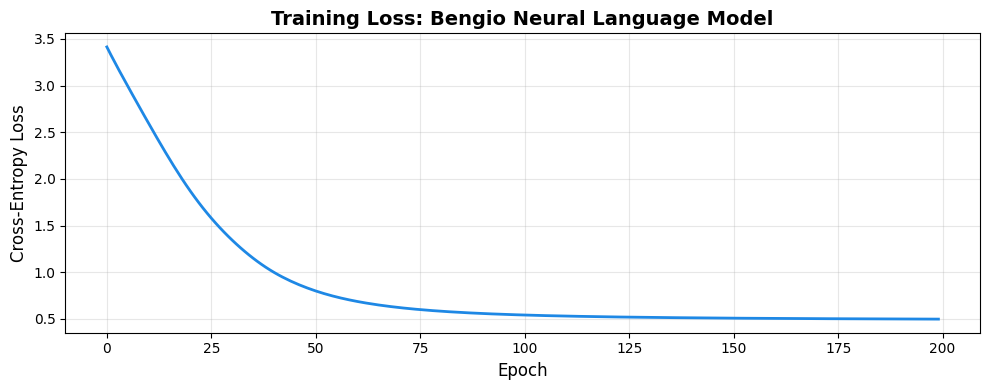

In [ ]:
# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(losses, color='#1E88E5', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Cross-Entropy Loss', fontsize=12)
plt.title('Training Loss: Bengio Neural Language Model', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

We can see the loss decreasing over epochs which tells us our model is successfully learning to predict the next word. This is a good sign that our embeddings are starting to capture meaningful relationships between words.

## Code Walkthrough: Visualize Embeddings

The real proof of concept for embeddings is seeing them visually. Now that our model has been trained, let's extract those learned word vectors and visualize them. We are hoping to see similar words clustered together, just like in our intuition example.

In the below code, we extract the embedding matrix from our trained model. Since our embeddings have 4 dimensions which is too many to plot directly, we use Principal Component Analysis (PCA) to reduce them to just two dimensions. This let's us visualize them on a 2D scatter plot. We have also added some code to color code the word by category like animals, surfaces, actions and locations to help us interpret the clusters.

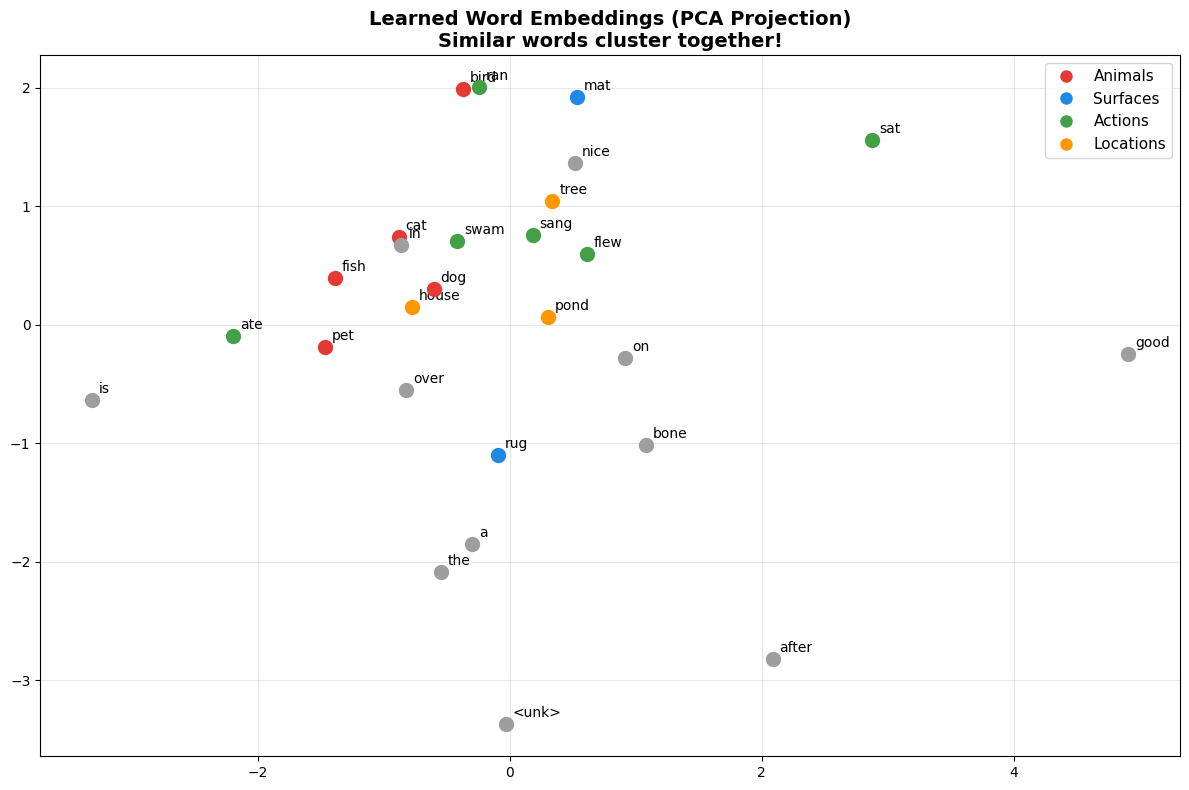

In [ ]:
# Extract learned embeddings and visualize with PCA
from sklearn.decomposition import PCA

# Get embedding vectors
with torch.no_grad():
    embedding_matrix = model.embeddings.weight.numpy()

# Reduce dimensions to 2D with PCA
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embedding_matrix)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))

# Color code by category
animals = {"cat", "dog", "bird", "fish", "pet"}
surfaces = {"mat", "rug"}
actions = {"sat", "ate", "ran", "flew", "swam", "sang"}
locations = {"tree", "house", "pond"}

for i, word in enumerate(vocab_list):
    x, y = embeddings_2d[i]

    if word in animals:
        color = '#E53935'
        category = 'animals'
    elif word in surfaces:
        color = '#1E88E5'
        category = 'surfaces'
    elif word in actions:
        color = '#43A047'
        category = 'actions'
    elif word in locations:
        color = '#FF9800'
        category = 'locations'
    else:
        color = '#9E9E9E'
        category = 'other'

    ax.scatter(x, y, c=color, s=100, zorder=5)
    ax.annotate(word, (x, y), textcoords="offset points",
                xytext=(5, 5), fontsize=10)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#E53935', markersize=10, label='Animals'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#1E88E5', markersize=10, label='Surfaces'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#43A047', markersize=10, label='Actions'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#FF9800', markersize=10, label='Locations'),
]
ax.legend(handles=legend_elements, loc='best', fontsize=11)
ax.set_title('Learned Word Embeddings (PCA Projection)\nSimilar words cluster together!',
             fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## What to Look For: Visualize Embeddings Results

Fantastic! Look at the above plot. We can clearly see that words like "cat", "dog", "fish" and "pet" — our animals — are grouped together. Similarly, "tree", "house" and "pond" — locations — form another cluster. This is exactly what we wanted to see. It shows that the model has learned semantic relationships and placed similar words nearby in the embedding space. This is a powerful demonstration of why Neural Language Models are so effective.

![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-ML-Explainers/main/assets/rainbow-divider.png)

# Word2Vec

In [1]:
# 🔧 Setup: Run this cell first!
# Check GPU availability and install dependencies

import torch
import sys

# Check GPU
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"✅ GPU available: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    device = torch.device('cpu')
    print("⚠️ No GPU detected. Some cells may run slowly.")
    print("   Go to Runtime → Change runtime type → GPU")

print(f"\n📦 Python {sys.version.split()[0]}")
print(f"🔥 PyTorch {torch.__version__}")

# Set random seeds for reproducibility
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"🎲 Random seed set to {SEED}")

%matplotlib inline

✅ GPU available: Tesla T4
   Memory: 15.6 GB

📦 Python 3.12.13
🔥 PyTorch 2.11.0+cu128
🎲 Random seed set to 42


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

## Code Walkthrough: Word2VecSkipGram Class

We are going to implement Word2Vec - specifically the **Skipgram** model. Word2Vec is famous for its powerful embeddings and it works by flipping the prediction task. Instead of predicting the next word from its context, **Skipgram predicts the context words from a given center word**. This approach is highly efficient for learning those rich word embeddings.

Given center word $w_c$, predict each context word $w_o$ within a window:

$$P(w_o \mid w_c) = \frac{\exp(v'_{w_o} \cdot v_{w_c})}{\sum_{w=1}^{V} \exp(v'_w \cdot v_{w_c})}$$

In [3]:
class Word2VecSkipGram(nn.Module):
    """
    Word2Vec Skipgram model.

    Given center word, predicts context words.
    """
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        # Two embedding layers for center words & context words
        self.center_embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.context_embeddings = nn.Embedding(vocab_size, embedding_dim)

    def forward(self, center_word, context_word):
        """
        Args:
            center_word: (batch_size,) indices of center words
            context_word: (batch_size,) indices of context words
        Returns:
            scores: (batch_size,) dot product scores
        """
        center_embed = self.center_embeddings(center_word)  # (batch_size, embedding_dim)
        context_embed = self.context_embeddings(context_word)  # (batch_size, embedding_dim)
        score = torch.sum(center_embed * context_embed, dim=1)  # (batch_size,)
        return score

## Code Walkthrough: Data Preparation

Skipgram flips the prediction task, so our data prep flips too. Where BengioLM took the two *previous* words to predict the next one, Skipgram takes a single center word and pairs it with each of its neighbours in a window centered on it. Our `WINDOW_SIZE` counts the total context words around the center, split evenly across both sides — so `WINDOW_SIZE = 2` means one word on each side. The center word "sat" in "the cat sat on the" would then generate pairs with "cat" and "on", its immediate neighbours. Each is a positive `(center, context)` pair — a real co-occurrence the model should learn to recognize.

In [23]:
# Prepare a corpus and vocabulary
corpus = [
    "the cat sat on the mat",
    "the dog sat on the rug",
    "the cat ate the fish",
    "the dog ate the bone",
    "the bird flew over the house",
    "the bird sat on the tree",
    "the cat ran after the dog",
    "the dog ran after the cat",
    "the fish swam in the pond",
    "the bird flew over the pond",
    "a cat sat on a mat",
    "a dog sat on a rug",
    "the cat is a nice pet",
    "the dog is a good pet",
    "a bird sang in the tree",
]

# Build vocabulary
all_words = []
for sentence in corpus:
    all_words.extend(sentence.lower().split())

word_counts = Counter(all_words)
vocab_list = ["<unk>"] + [w for w, c in word_counts.most_common()]
word2idx = {w: i for i, w in enumerate(vocab_list)}
idx2word = {i: w for w, i in word2idx.items()}

print(f"Vocabulary: {len(word2idx)} words")
print(f"Words: {vocab_list}")

Vocabulary: 27 words
Words: ['<unk>', 'the', 'a', 'cat', 'dog', 'sat', 'on', 'bird', 'mat', 'rug', 'ate', 'fish', 'flew', 'over', 'tree', 'ran', 'after', 'in', 'pond', 'is', 'pet', 'bone', 'house', 'swam', 'nice', 'good', 'sang']


In [24]:
# Create training data: (center, context) positive pairs for Word2Vec Skipgram
WINDOW_SIZE = 4  # Total context words around the center (1 on each side)

def make_skipgram_data(corpus, window_size, word2idx):
    """Create (center, context) positive pairs from corpus.

    window_size is the TOTAL number of context words around the center,
    split evenly across both sides. So window_size=2 means 1 word per side.
    """
    half_window = window_size // 2
    pairs = []
    for sentence in corpus:
        tokens = sentence.lower().split()
        for i, center_token in enumerate(tokens):
            center = word2idx.get(center_token, 0)
            start = max(0, i - half_window)
            end = min(len(tokens), i + half_window + 1)
            for j in range(start, end):
                if j == i:
                    continue  # skip the center word itself
                context = word2idx.get(tokens[j], 0)
                pairs.append((center, context))
    return pairs

skipgram_pairs = make_skipgram_data(corpus, WINDOW_SIZE, word2idx)

# Positive pairs as tensors (reused every epoch)
centers_pos = torch.tensor([c for c, ctx in skipgram_pairs])
contexts_pos = torch.tensor([ctx for c, ctx in skipgram_pairs])

print(f"Positive training pairs: {len(skipgram_pairs)}")
print(f"\nFirst 5 pairs:")
for i in range(5):
    c, ctx = skipgram_pairs[i]
    print(f"  Center: '{idx2word[c]}' → Context: '{idx2word[ctx]}'")

Positive training pairs: 262

First 5 pairs:
  Center: 'the' → Context: 'cat'
  Center: 'the' → Context: 'sat'
  Center: 'cat' → Context: 'the'
  Center: 'cat' → Context: 'sat'
  Center: 'cat' → Context: 'on'


## Code Walkthrough: Train Word2VecSkipGram Model

Here the training differs in an important way from BengioLM. Because our model produces a single dot-product score per pair rather than logits over the whole vocabulary, we train it as a binary classification problem with **Cross-Entropy on a single logit** (`BCEWithLogitsLoss`): real `(center, context)` pairs should score high (label 1), while random `(center, fake_word)` pairs should score low (label 0). This is the **negative sampling trick** that made Word2Vec so efficient.

We draw `NUM_NEGATIVES` fake context words for every real pair, sampling them from a smoothed unigram distribution where $P(w) ∝ frequency(w)^{0.75}$. This dampens the pull of very common words like "the" while still sampling them often. We resample fresh negatives each epoch.

In [28]:
import numpy as np

# Build the negative-sampling distribution: P(w) ∝ freq(w)^0.75
word_freqs = np.array([word_counts.get(w, 0) for w in vocab_list], dtype=np.float64)
unigram_dist = word_freqs ** 0.75
unigram_dist = unigram_dist / unigram_dist.sum()  # <unk> has freq 0, so it's never sampled

# Hyperparameters
EMBED_DIM = 4
LEARNING_RATE = 0.01
EPOCHS = 200
NUM_NEGATIVES = 7

w2v_model = Word2VecSkipGram(vocab_size=len(word2idx), embedding_dim=EMBED_DIM)
optimizer = torch.optim.Adam(w2v_model.parameters(), lr=LEARNING_RATE)
criterion = nn.BCEWithLogitsLoss()

num_pos = len(skipgram_pairs)
w2v_losses = []

for epoch in range(EPOCHS):
    # Positive samples: real (center, context) pairs → label 1
    pos_scores = w2v_model(centers_pos, contexts_pos)
    pos_labels = torch.ones_like(pos_scores)

    # Negative samples: same centers, random contexts → label 0
    neg_centers = centers_pos.repeat_interleave(NUM_NEGATIVES)
    neg_context_idx = np.random.choice(len(vocab_list),
                                       size=num_pos * NUM_NEGATIVES,
                                       p=unigram_dist)
    neg_contexts = torch.tensor(neg_context_idx, dtype=torch.long)
    neg_scores = w2v_model(neg_centers, neg_contexts)
    neg_labels = torch.zeros_like(neg_scores)

    # Combine positives + negatives and compute loss
    scores = torch.cat([pos_scores, neg_scores])
    labels = torch.cat([pos_labels, neg_labels])
    loss = criterion(scores, labels)

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    w2v_losses.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {loss.item():.4f}")

Epoch 10/200, Loss: 0.8864
Epoch 20/200, Loss: 0.8582
Epoch 30/200, Loss: 0.7463
Epoch 40/200, Loss: 0.7093
Epoch 50/200, Loss: 0.6586
Epoch 60/200, Loss: 0.6269
Epoch 70/200, Loss: 0.5836
Epoch 80/200, Loss: 0.5453
Epoch 90/200, Loss: 0.4998
Epoch 100/200, Loss: 0.4637
Epoch 110/200, Loss: 0.4540
Epoch 120/200, Loss: 0.4260
Epoch 130/200, Loss: 0.4122
Epoch 140/200, Loss: 0.3936
Epoch 150/200, Loss: 0.3822
Epoch 160/200, Loss: 0.3807
Epoch 170/200, Loss: 0.3717
Epoch 180/200, Loss: 0.3678
Epoch 190/200, Loss: 0.3657
Epoch 200/200, Loss: 0.3623


## What to Look For: Train Word2VecSkipGram Results

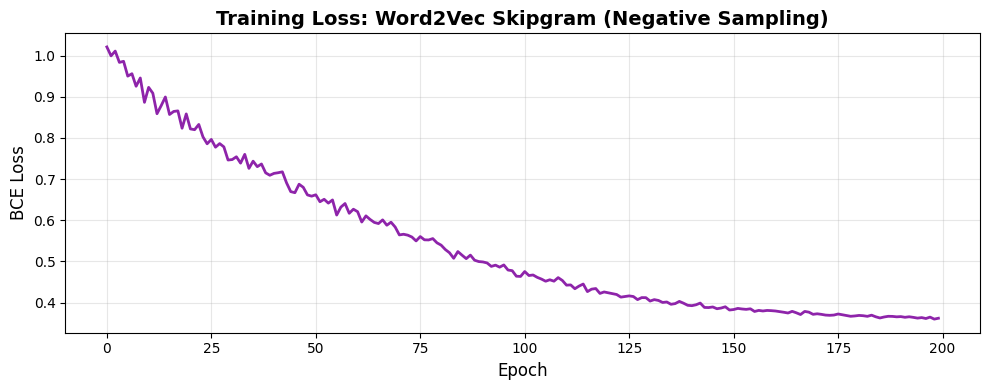

In [29]:
# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(w2v_losses, color='#8E24AA', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('BCE Loss', fontsize=12)
plt.title('Training Loss: Word2Vec Skipgram (Negative Sampling)', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The loss drops as the model gets better at telling real neighbours apart from random words — it's learning that "cat" genuinely co-occurs with "sat" but not with "pond". You may notice the curve is slightly jagged rather than perfectly smooth: that's expected here, because we draw a *fresh* set of random negatives every epoch, so each step faces a slightly different batch. The overall downward trend is what matters.

## Code Walkthrough: Visualize Embeddings

Just like with BengioLM, the real test is whether the learned vectors capture meaning. Word2Vec keeps two embedding tables — one for center words and one for context words — and by convention we use the **center embeddings** as the final word vectors. We pull those out and project them from 4 dimensions down to 2 with PCA, reusing the same category colors so the plot reads the same way as the BengioLM one.

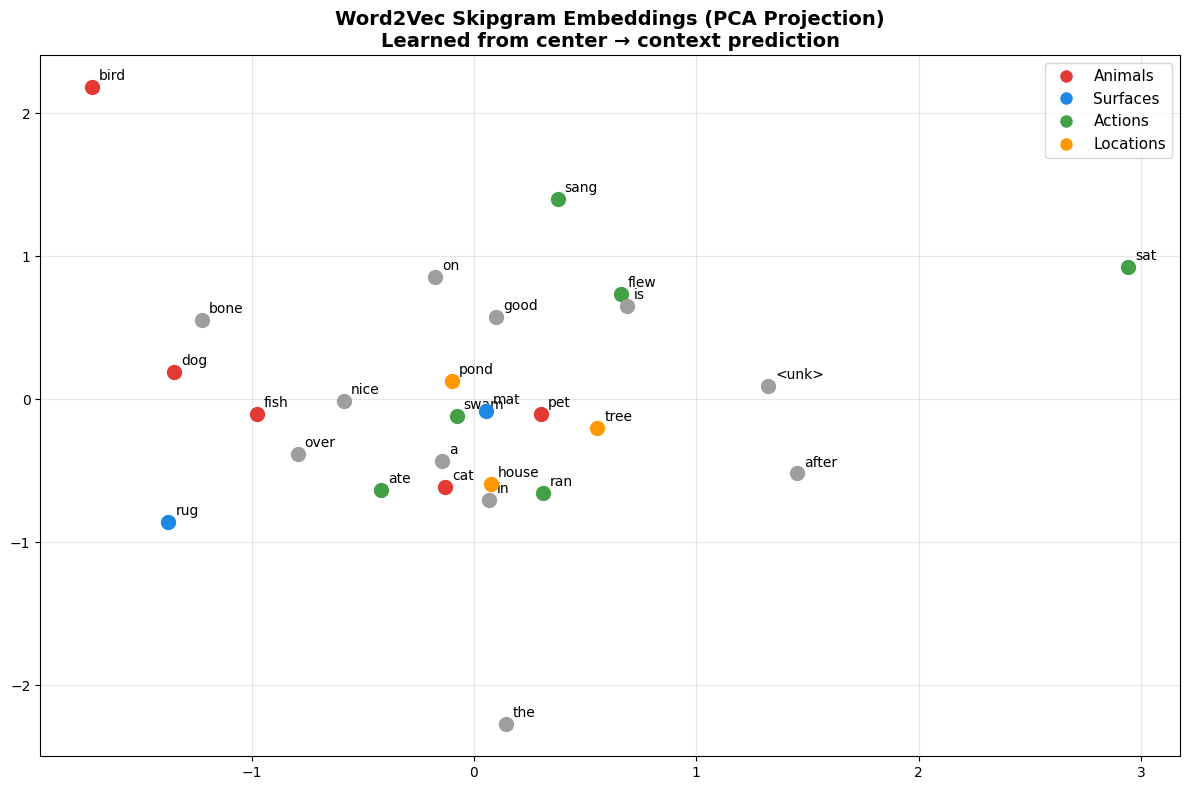

In [30]:
# Extract learned embeddings and visualize with PCA
from sklearn.decomposition import PCA

# Extract learned center embeddings and visualize with PCA
with torch.no_grad():
    w2v_embedding_matrix = w2v_model.center_embeddings.weight.numpy()

pca = PCA(n_components=2)
w2v_embeddings_2d = pca.fit_transform(w2v_embedding_matrix)

fig, ax = plt.subplots(figsize=(12, 8))

animals = {"cat", "dog", "bird", "fish", "pet"}
surfaces = {"mat", "rug"}
actions = {"sat", "ate", "ran", "flew", "swam", "sang"}
locations = {"tree", "house", "pond"}

for i, word in enumerate(vocab_list):
    x, y = w2v_embeddings_2d[i]
    if word in animals:
        color = '#E53935'
    elif word in surfaces:
        color = '#1E88E5'
    elif word in actions:
        color = '#43A047'
    elif word in locations:
        color = '#FF9800'
    else:
        color = '#9E9E9E'
    ax.scatter(x, y, c=color, s=100, zorder=5)
    ax.annotate(word, (x, y), textcoords="offset points", xytext=(5, 5), fontsize=10)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#E53935', markersize=10, label='Animals'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#1E88E5', markersize=10, label='Surfaces'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#43A047', markersize=10, label='Actions'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#FF9800', markersize=10, label='Locations'),
]
ax.legend(handles=legend_elements, loc='best', fontsize=11)
ax.set_title('Word2Vec Skipgram Embeddings (PCA Projection)\nLearned from center → context prediction',
             fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## What to Look For: Visualize Embeddings Results

You should again see related words drifting toward one another — animals near other animals, actions grouping up — confirming that a completely different training objective (predict the context, not the next word) arrives at the same kind of semantic structure. That convergence is the real point: meaning emerges from co-occurrence, whichever direction you predict in.

## Measure Cosine Similarity Between Word Pairs

![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-ML-Explainers/main/assets/rainbow-divider.png)

# References

- **[Vizuara AI](https://vizuara.ai/)**
- **Key Papers:**
  - **Bengio, Y. et al. (2003). "A Neural Probabilistic Language Model"**
  - **Mikolov, T. et al. (2013). "Efficient Estimation of Word Representations in Vector Space"**

![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-ML-Explainers/main/assets/rainbow-divider.png)